# Checkpoint 4 — Questão 2: Gestão inteligente do consumo de energia

**Integrantes:** Felipe Bernardes (RM564360) · Guilherme Romero (RM564431)

Os algoritmos estão em `src/brute_force.py` e `src/divide_conquer.py`; aqui eles são executados e explicados.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display
from src.config import SEED, INTEGRANTES, FIG_DIR
pd.set_option("display.max_rows", 60)
print("SEED =", SEED)
for nome, rm in INTEGRANTES:
    print(f"  {nome} — {rm}")

SEED = 564360
  Felipe Bernardes — RM564360
  Guilherme Romero — RM564431


## Parte A — Dados e estruturas

Geração em `src/dados_q2.py` (reprodutível pela SEED): 5 regiões × 336 h (14 dias) = **1.680 observações** com
`timestamp, regiao, consumo, capacidade, prioridade, custo`. O modelo produz a "curva do pato": capacidade sobra ao
meio-dia (solar) e aperta no começo da noite; ondas de calor e falhas de geração criam episódios críticos.

In [2]:
from src.questao2 import obter_indice
indice = obter_indice()
df = pd.DataFrame(indice.registros)
print(len(df), "observações")
df.head(8)

1680 observações


,timestamp,regiao,consumo,capacidade,prioridade,custo
0,2026-01-05 00:00:00,Centro-Oeste,801.18,1100.0,4,173.59
1,2026-01-05 00:00:00,Nordeste,1417.31,1840.0,2,174.50
2,2026-01-05 00:00:00,Norte,655.91,880.0,4,180.77
3,2026-01-05 00:00:00,Sudeste,3875.45,5350.0,3,172.49
4,2026-01-05 00:00:00,Sul,1555.39,2080.0,3,170.18
5,2026-01-05 01:00:00,Centro-Oeste,805.57,1100.0,2,187.49
6,2026-01-05 01:00:00,Nordeste,1329.03,1840.0,2,183.37
7,2026-01-05 01:00:00,Norte,629.15,880.0,3,177.58


| Estrutura | Uso em `IndiceEnergia` | Vantagem |
|---|---|---|
| `list` ordenada no tempo | série de cada região | acesso por índice O(1) e fatias contínuas — é a entrada dos algoritmos |
| `tuple` (`NamedTuple Registro`) | cada medição | imutável e ~3× mais leve que dict |
| `dict` região → índices | consumo por região | O(1) para achar a região + O(k) para percorrê-la |
| `dict` hora → índices | consumo por horário | idem, por hora do dia |
| `set` de (timestamp, região) | horas em sobrecarga | pertinência O(1) |
| `heap` (`heapq.nlargest`) | top-k picos | O(n log k) em vez de ordenar tudo O(n log n) |
| `list` + `bisect` + prefixos | seleção/soma de intervalo | O(log n) para achar os limites, O(1) para somar |

In [3]:
from datetime import datetime
print("Consumo por região (MWh):", {k: round(v) for k, v in indice.consumo_por_regiao().items()})
print("\nTop-5 picos:")
for r in indice.picos(5): print("  ", r.timestamp, r.regiao, r.consumo)
print("\nHoras em sobrecarga:", len(indice.sobrecarga))
print("Períodos críticos do Sudeste:", [(a.strftime('%d/%m %Hh'), b.strftime('%d/%m %Hh')) for a, b in indice.periodos_criticos("Sudeste")])
ini, fim = datetime(2026, 1, 16, 17), datetime(2026, 1, 16, 22)
print("Consumo Sudeste 16/01 17h–22h:", round(indice.consumo_no_intervalo("Sudeste", ini, fim), 1), "MWh")
pd.Series(indice.consumo_medio_por_hora()).plot(kind="bar", figsize=(10, 3), title="consumo médio por hora do dia");

Consumo por região (MWh): {'Centro-Oeste': 269501, 'Nordeste': 472611, 'Norte': 216727, 'Sudeste': 1344134, 'Sul': 525169}

Top-5 picos:
   2026-01-16 18:00:00 Sudeste 5954.86
   2026-01-14 19:00:00 Sudeste 5946.1
   2026-01-16 19:00:00 Sudeste 5825.35
   2026-01-15 19:00:00 Sudeste 5766.43
   2026-01-14 20:00:00 Sudeste 5722.23

Horas em sobrecarga: 84
Períodos críticos do Sudeste: [('05/01 19h', '05/01 19h'), ('07/01 21h', '07/01 21h'), ('08/01 18h', '08/01 18h'), ('08/01 21h', '08/01 21h'), ('14/01 18h', '14/01 20h'), ('15/01 18h', '15/01 21h'), ('16/01 18h', '16/01 21h'), ('17/01 20h', '17/01 20h')]
Consumo Sudeste 16/01 17h–22h: 33196.9 MWh


### Função de criticidade

$$c_t = 100(\text{carga}_t - 0{,}88) + 300\max(0, \text{carga}_t - 1) + 2(\text{prioridade}_t - 3) + 5(\text{custo}_t/250 - 1)$$

com carga = consumo/capacidade. Horas folgadas ficam **negativas**; o problema vira achar o subvetor contínuo de soma máxima.

In [4]:
from src.dados_q2 import serie_criticidade
serie = indice.serie("Sul")
crit = serie_criticidade(serie)
print(f"{sum(c > 0 for c in crit)} de {len(crit)} horas com criticidade positiva; min={min(crit):.1f} max={max(crit):.1f}")

55 de 336 horas com criticidade positiva; min=-44.4 max=65.9


## Parte B — Força bruta

Para cada início *i* e cada fim *j ≥ i* avalia o intervalo [i, j] (soma incremental). São n(n+1)/2 intervalos → Θ(n²).
A versão literal Θ(n³) (`intervalo_critico_ingenuo`) recalcula cada soma do zero.

In [5]:
from src.brute_force import intervalo_critico_forca_bruta, intervalo_critico_ingenuo
from src.metricas import Contador
c1, c2 = Contador(), Contador()
fb = intervalo_critico_forca_bruta(crit, c1)
ing = intervalo_critico_ingenuo(crit[:120], c2)
print("Força bruta:", fb, "| ops =", c1.operacoes, "= n(n+1)/2 =", len(crit)*(len(crit)+1)//2)
print(f"Horas: {serie[fb.inicio].timestamp:%d/%m %Hh} → {serie[fb.fim].timestamp:%d/%m %Hh}")
print("Versão ingênua nas 120 primeiras horas: ops =", c2.operacoes)

Força bruta: Intervalo(inicio=257, fim=261, soma=212.5167409407527) | ops = 56616 = n(n+1)/2 = 56616
Horas: 15/01 17h → 15/01 21h
Versão ingênua nas 120 primeiras horas: ops = 295240


## Parte C — Dividir e Conquistar

`DIVIDE → SOLVE LEFT → SOLVE RIGHT → SOLVE CROSSING → COMBINE`

* **caso-base**: 1 elemento → o próprio elemento;
* **divisão**: meio = (lo+hi)//2;
* **cruzamento**: melhor sufixo terminando em `meio` + melhor prefixo começando em `meio+1` (O(n) no nó);
* **combinação**: máximo entre esquerda, direita e cruzamento.

Traço dos 3 primeiros níveis nos dados reais:

In [6]:
from src.divide_conquer import intervalo_critico_dc
c3 = Contador()
dc, arvore = intervalo_critico_dc(crit, c3, profundidade_registro=3)
print("D&C:", dc, "| ops =", c3.operacoes, "| igual à força bruta:", abs(dc.soma - fb.soma) < 1e-9)

def mostrar(no, recuo=""):
    if no.cruzamento is None:
        return
    print(f"{recuo}[{no.lo:>3},{no.hi:>3}] E={no.esquerda_melhor.soma:7.1f} D={no.direita_melhor.soma:7.1f} "
          f"X={no.cruzamento.soma:7.1f} → {no.origem}")
    for f in no.filhos: mostrar(f, recuo + "    ")
mostrar(arvore)

D&C: Intervalo(inicio=257, fim=261, soma=212.51674094075275) | ops = 3184 | igual à força bruta: True
[  0,335] E=   46.1 D=  212.5 X=  -27.0 → direita
    [  0,167] E=   25.9 D=   46.1 X=  -64.8 → direita
        [  0, 83] E=   25.9 D=   23.3 X=    5.2 → esquerda
            [  0, 41] E=   15.9 D=   10.0 X=   25.9 → cruzamento
            [ 42, 83] E=   16.1 D=   23.3 X=  -29.3 → direita
        [ 84,167] E=   46.1 D=    3.1 X=  -71.1 → esquerda
            [ 84,125] E=   46.1 D=   35.3 X=  -76.3 → esquerda
            [126,167] E=   -0.5 D=    3.1 X=  -59.0 → direita
    [168,335] E=  150.4 D=  212.5 X=  119.4 → direita
        [168,251] E=   37.8 D=  150.4 X=  132.7 → direita
            [168,209] E=   31.5 D=    7.7 X=   37.8 → cruzamento
            [210,251] E=  125.0 D=  150.4 X=  117.3 → direita
        [252,335] E=  212.5 D=   58.7 X=  -19.3 → esquerda
            [252,293] E=  212.5 D=  143.9 X=   30.8 → esquerda
            [294,335] E=   58.7 D=    3.5 X=  -19.6 → esquerda


## Parte D — Experimento de escalabilidade

In [7]:
from src.experimento import rodar, extrapolar
linhas = rodar()
esc = pd.DataFrame(linhas)
esc["tempo_ms"] = esc.tempo_s * 1000
esc[["algoritmo", "n", "tempo_ms", "operacoes", "memoria_pico_kb", "tempo_por_n2_ns", "tempo_por_nlogn_ns"]].round(2)

  n=  100 forca_bruta               0.40 ms  ops=      5,050  mem=     0.2 KB
  n=  100 dividir_conquistar        0.18 ms  ops=        772  mem=     0.6 KB
  n=  250 forca_bruta               2.38 ms  ops=     31,375  mem=     0.2 KB
  n=  250 dividir_conquistar        0.46 ms  ops=      2,244  mem=     0.7 KB


  n=  500 forca_bruta              10.31 ms  ops=    125,250  mem=     3.5 KB

  n=  500 dividir_conquistar        1.03 ms  ops=      4,988  mem=     3.4 KB


  n= 1000 forca_bruta              43.23 ms  ops=    500,500  mem=     3.2 KB
  n= 1000 dividir_conquistar        2.23 ms  ops=     10,976  mem=     2.0 KB


  n= 2000 forca_bruta             171.19 ms  ops=  2,001,000  mem=     0.4 KB
  n= 2000 dividir_conquistar        4.67 ms  ops=     23,952  mem=     2.1 KB


  n= 5000 forca_bruta            1059.80 ms  ops= 12,502,500  mem=     1.4 KB


  n= 5000 dividir_conquistar       11.72 ms  ops=     66,808  mem=     3.5 KB


,algoritmo,n,tempo_ms,operacoes,memoria_pico_kb,tempo_por_n2_ns,tempo_por_nlogn_ns
0,forca_bruta,100,0.40,5050,0.25,40.39,607.88
1,dividir_conquistar,100,0.18,772,0.61,17.83,268.39
2,forca_bruta,250,2.38,31375,0.25,38.06,1194.44
3,dividir_conquistar,250,0.46,2244,0.68,7.36,230.86
4,forca_bruta,500,10.31,125250,3.55,41.25,2300.17
5,dividir_conquistar,500,1.03,4988,3.38,4.12,229.96
6,forca_bruta,1000,43.23,500500,3.15,43.23,4337.44
7,dividir_conquistar,1000,2.23,10976,2.04,2.23,224.05
8,forca_bruta,2000,171.19,2001000,0.41,42.80,7805.70
9,dividir_conquistar,2000,4.67,23952,2.14,1.17,213.10


**Interpretação.** Na força bruta a coluna `tempo/n²` fica praticamente constante (~40 ns) enquanto `tempo/(n log n)` cresce —
confirma Θ(n²). No D&C é o contrário: `tempo/(n log n)` estabiliza (~200 ns) e `tempo/n²` despenca — confirma Θ(n log n).
Dobrar n (1000 → 2000) multiplica o tempo da força bruta por ≈ 4 e o do D&C por ≈ 2,1.
A memória da força bruta é constante; a do D&C cresce devagar, acompanhando a profundidade ⌈log₂ n⌉ da pilha.

In [8]:
e = extrapolar(linhas)
print(f"n = 1.000.000 → força bruta ≈ {e['forca_bruta_s']/3600:.1f} h ({e['forca_bruta_ops']:.2e} operações)")
print(f"               D&C ≈ {e['dividir_conquistar_s']:.1f} s (~{e['dividir_conquistar_ops_aprox']:.2e} operações), "
      f"profundidade de recursão {e['profundidade_recursao']}")

n = 1.000.000 → força bruta ≈ 11.8 h (5.00e+11 operações)
               D&C ≈ 3.8 s (~2.19e+07 operações), profundidade de recursão 20


## Parte E — Figuras

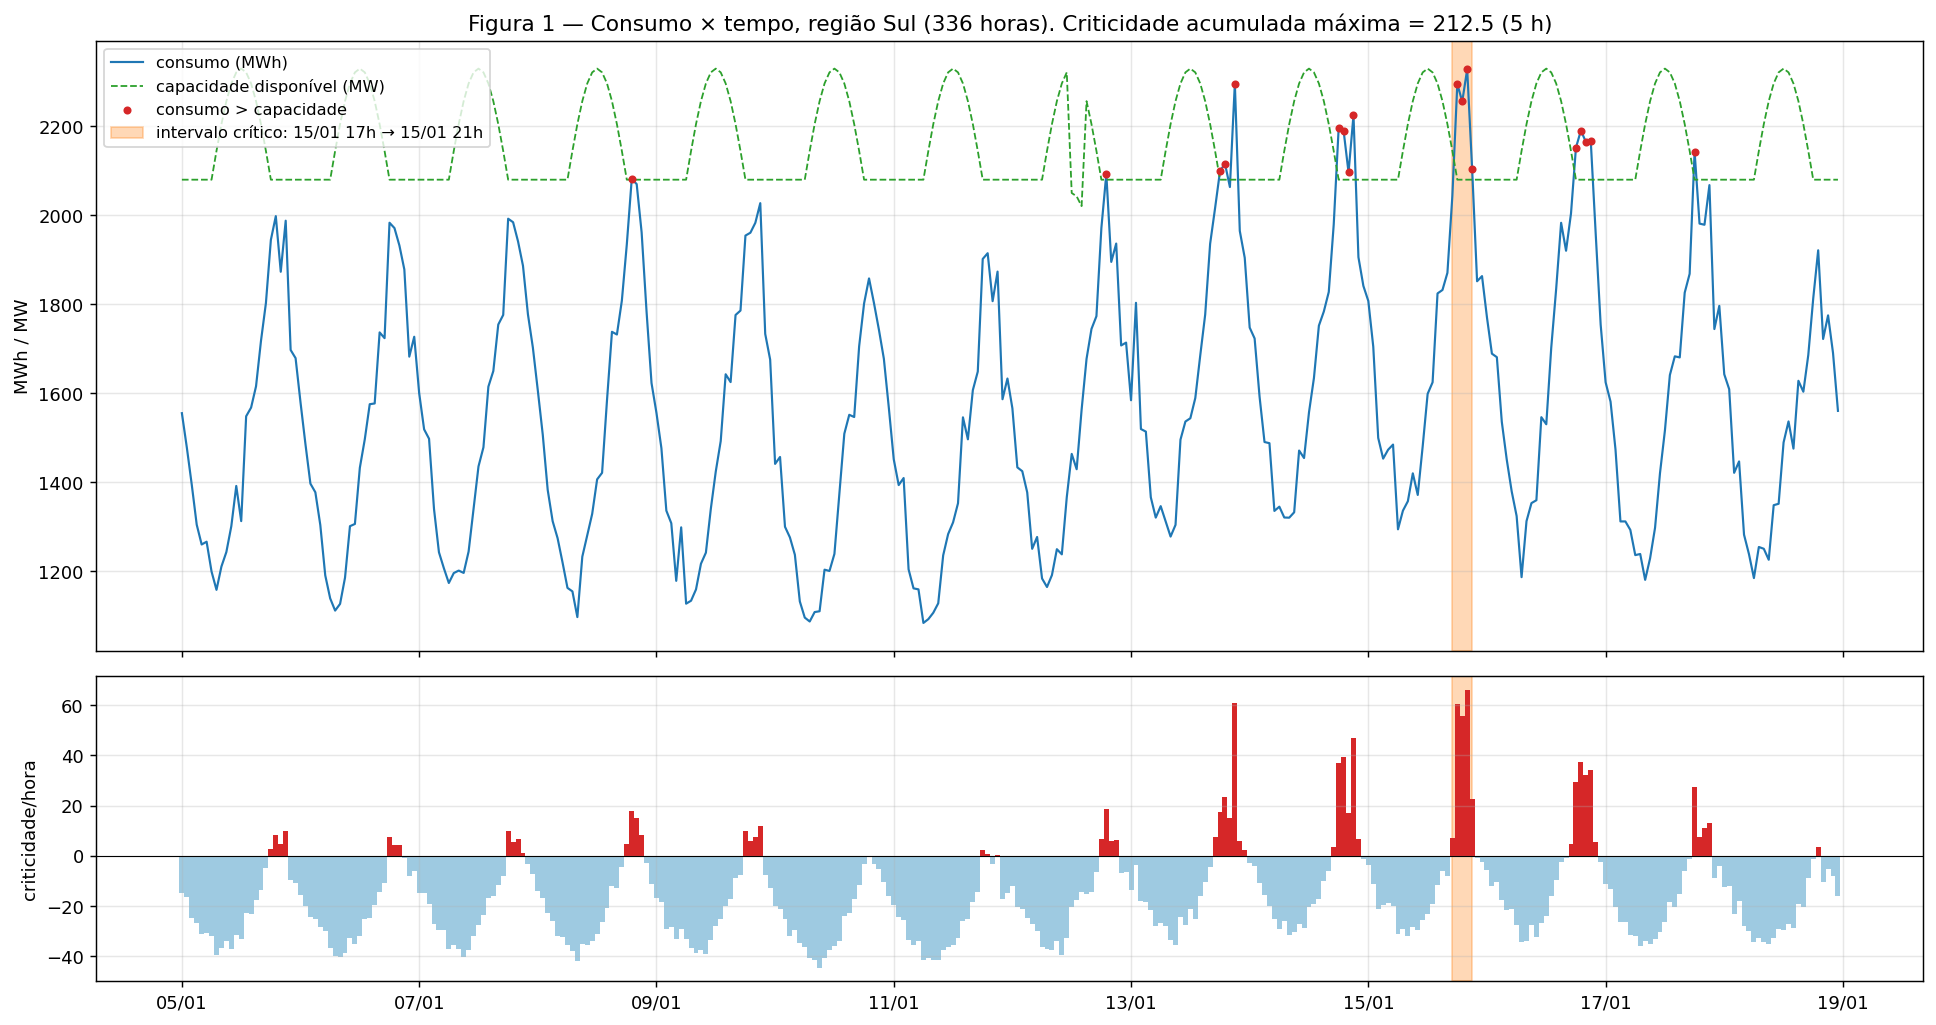

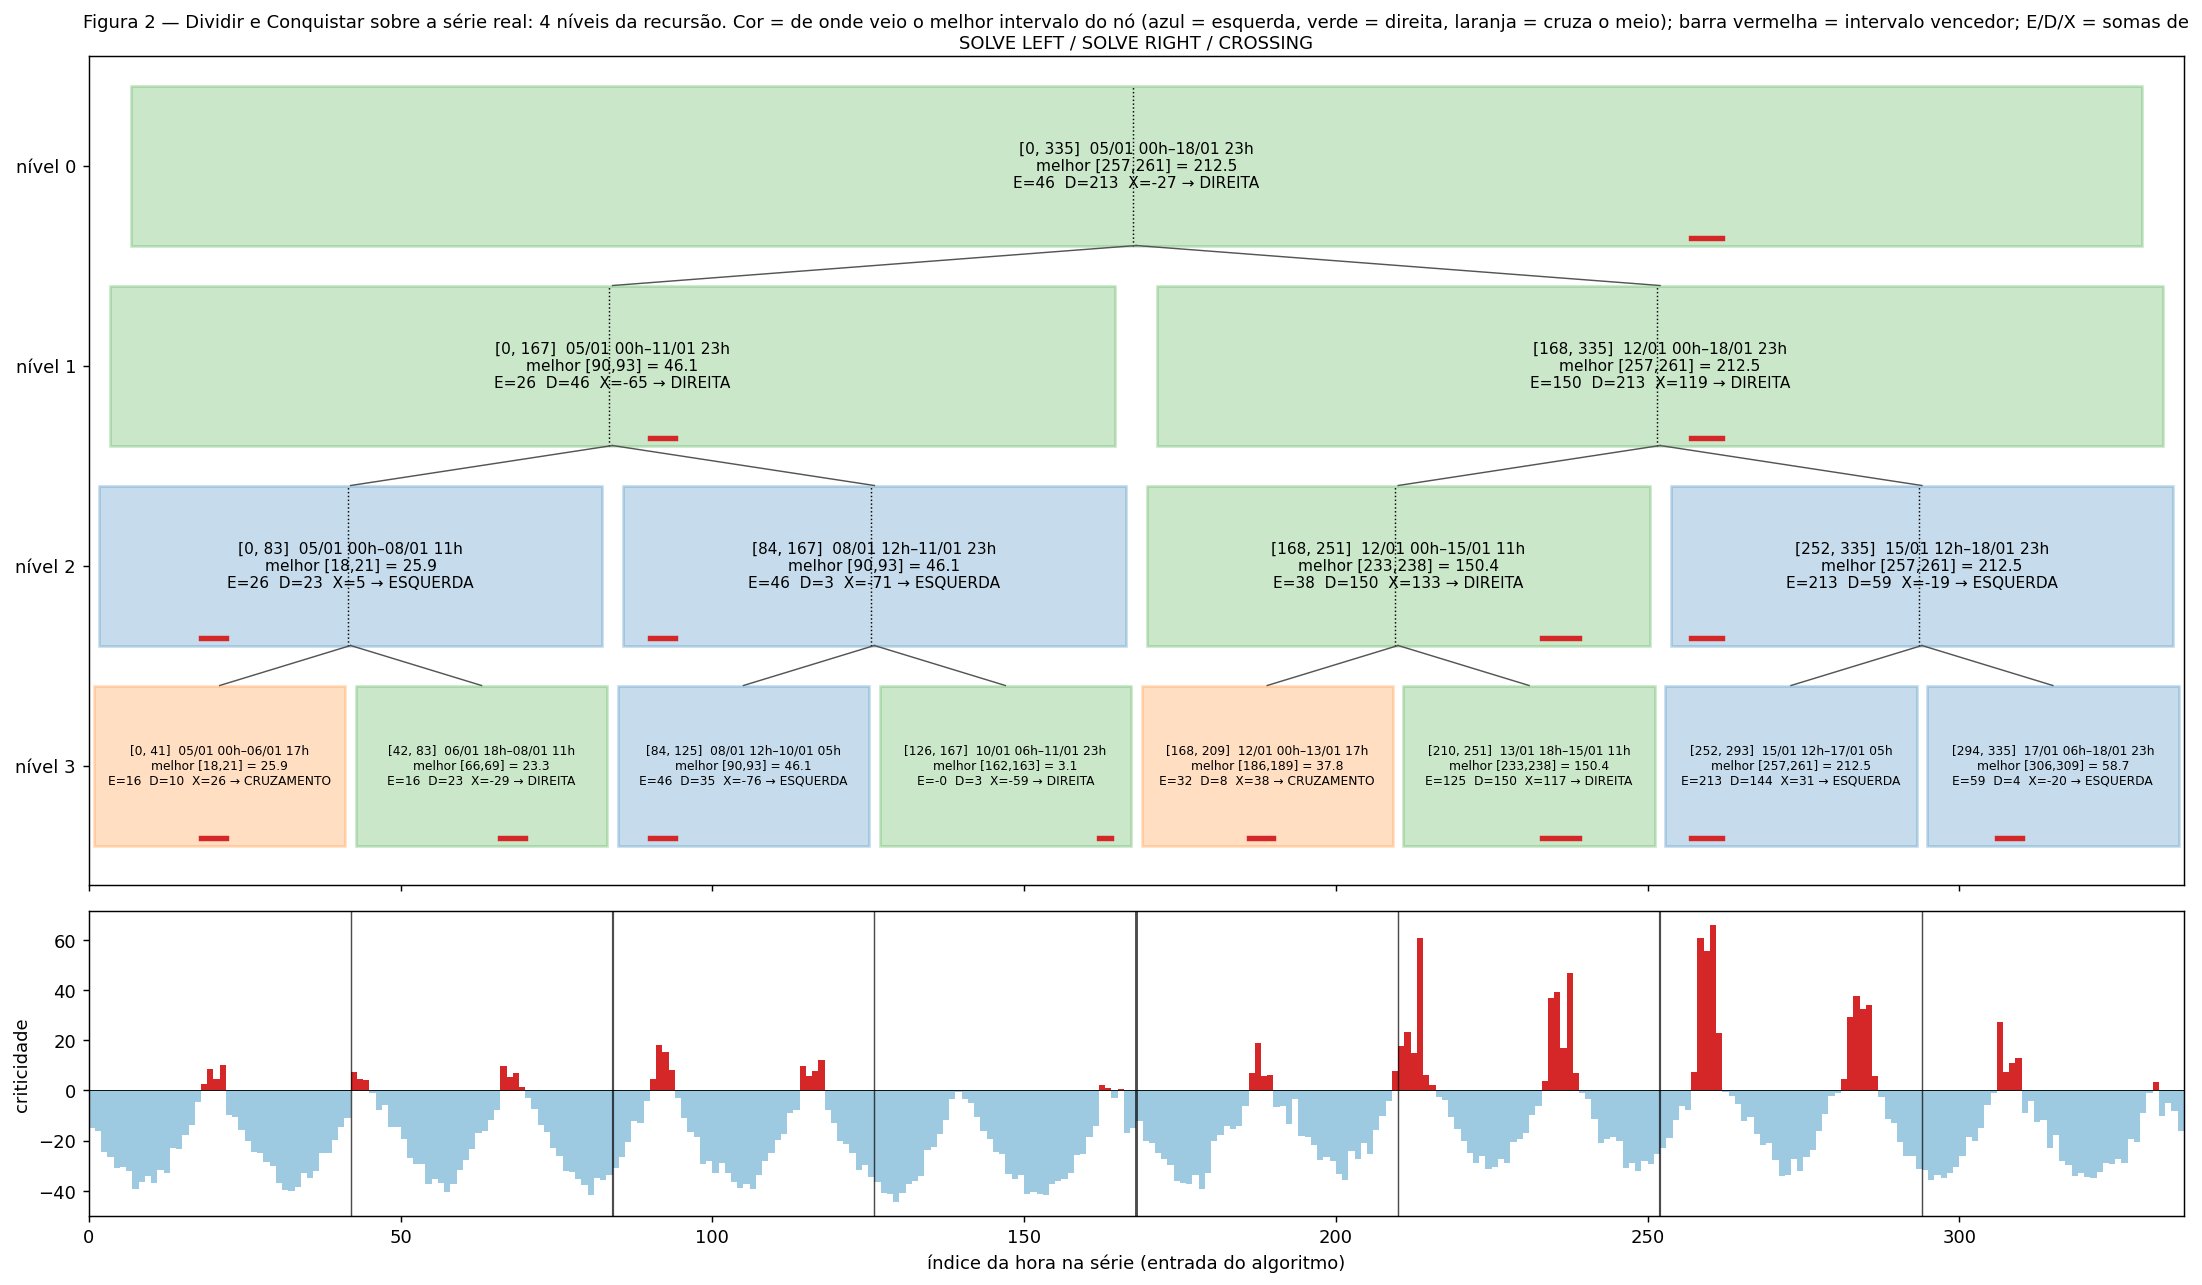

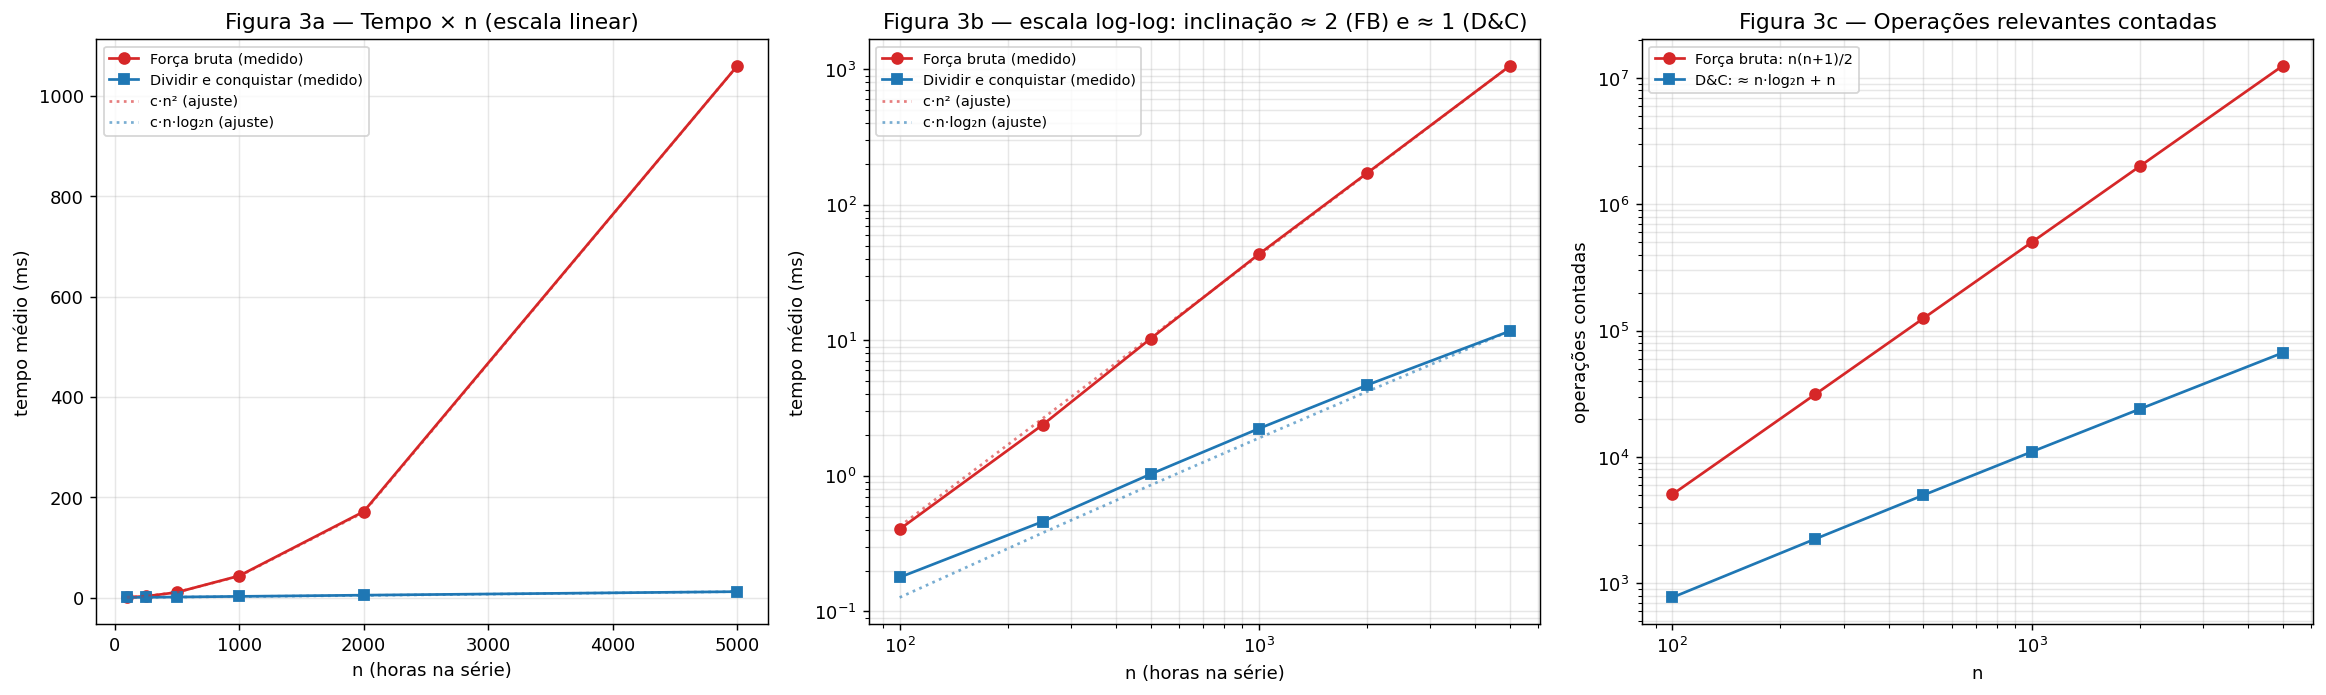

In [9]:
from src import visualizacao_q2 as viz
viz.figura_serie(serie, crit, dc, "Sul", FIG_DIR / "questao2" / "fig1_serie_temporal.png")
viz.figura_decomposicao(arvore, crit, serie, FIG_DIR / "questao2" / "fig2_dividir_conquistar.png")
viz.figura_escalabilidade(linhas, FIG_DIR / "questao2" / "fig3_escalabilidade.png")
for nome in ["fig1_serie_temporal", "fig2_dividir_conquistar", "fig3_escalabilidade"]:
    display(Image(filename=str(FIG_DIR / "questao2" / f"{nome}.png")))

## Simulação de alteração de intervalo (defesa)

**Previsão:** se analisarmos apenas as horas 0–199 do Sul, o intervalo de 15/01 (índices 257–261) sai da janela.
Pela Figura 2, o nó [0, 167] tem como melhor intervalo [90, 93] = 46,1, e no trecho [168, 199] o maior episódio visível é
[186, 189] = 37,8. Logo a resposta deve ser [90, 93] com criticidade ≈ 46,1.

In [10]:
sub = crit[:200]
print("Força bruta:", intervalo_critico_forca_bruta(sub))
print("D&C        :", intervalo_critico_dc(sub)[0])

Força bruta: Intervalo(inicio=90, fim=93, soma=46.07655384615383)
D&C        : Intervalo(inicio=90, fim=93, soma=46.07655384615383)
